In [556]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [557]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [558]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification

In [559]:
X,y = make_classification(n_samples=1000, n_features=2, n_classes=2, n_redundant=0,n_clusters_per_class=2)

<Axes: xlabel='0', ylabel='1'>

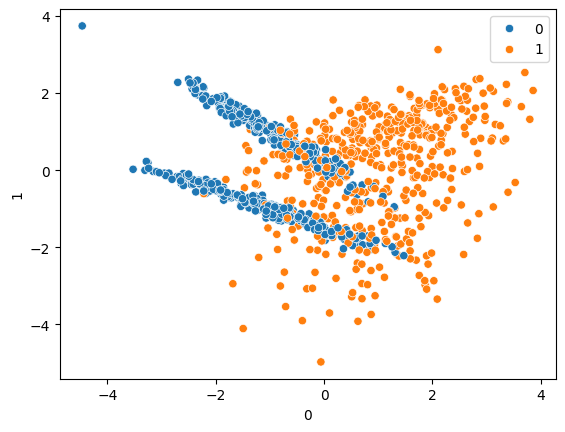

In [560]:
sns.scatterplot(x= pd.DataFrame(X)[0],y= pd.DataFrame(X)[1],hue=y)

In [565]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=10)

In [566]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report,confusion_matrix

In [567]:
svc = SVC(kernel="linear")
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)

In [569]:
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.77      0.77      0.77        97
           1       0.79      0.79      0.79       103

    accuracy                           0.78       200
   macro avg       0.78      0.78      0.78       200
weighted avg       0.78      0.78      0.78       200

[[75 22]
 [22 81]]


In [ ]:
rbf = SVC(kernel="rbf")
rbf.fit(X_train, y_train)
y_pred1 = rbf.predict(X_test)
print(classification_report(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))

              precision    recall  f1-score   support

           0       0.80      0.85      0.82        97
           1       0.85      0.80      0.82       103

    accuracy                           0.82       200
   macro avg       0.82      0.82      0.82       200
weighted avg       0.82      0.82      0.82       200

[[82 15]
 [21 82]]


In [571]:
poly = SVC(kernel="poly")
poly.fit(X_train, y_train)
y_pred2 = poly.predict(X_test)
print(classification_report(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2)) 

              precision    recall  f1-score   support

           0       0.72      0.84      0.78        97
           1       0.82      0.70      0.75       103

    accuracy                           0.77       200
   macro avg       0.77      0.77      0.76       200
weighted avg       0.77      0.77      0.76       200

[[81 16]
 [31 72]]


In [572]:
sig = SVC(kernel="sigmoid")
sig.fit(X_train, y_train)
y_pred3 = sig.predict(X_test)
print(classification_report(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3)) 

              precision    recall  f1-score   support

           0       0.74      0.73      0.74        97
           1       0.75      0.76      0.75       103

    accuracy                           0.74       200
   macro avg       0.74      0.74      0.74       200
weighted avg       0.74      0.74      0.74       200

[[71 26]
 [25 78]]


hyperparameter tuning 

In [574]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C':[0.1,1,10,100],'gamma':[1,0.1,0.01,0.001],'kernel':['rbf']}

grid= GridSearchCV(SVC(),param_grid,cv = 5 , verbose =3 , refit = True)

In [575]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.881 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.812 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.856 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.869 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.875 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.881 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.819 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.844 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.838 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.844 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.887 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf;

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001],
                         'kernel': ['rbf']},
             verbose=3)

In [ ]:
grid.best_params_

{'C': 100, 'gamma': 1, 'kernel': 'rbf'}

In [578]:
rbf = SVC(kernel="rbf")
rbf.fit(X_train, y_train)
y_pred1 = rbf.predict(X_test)
print(classification_report(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))

              precision    recall  f1-score   support

           0       0.80      0.85      0.82        97
           1       0.85      0.80      0.82       103

    accuracy                           0.82       200
   macro avg       0.82      0.82      0.82       200
weighted avg       0.82      0.82      0.82       200

[[82 15]
 [21 82]]


In [ ]:
y_pred4 = grid.predict(X_test)
print(classification_report(y_test,y_pred4))
print(confusion_matrix(y_test,y_pred4))


              precision    recall  f1-score   support

           0       0.90      0.92      0.91        97
           1       0.92      0.90      0.91       103

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.91      0.91      0.91       200

[[89  8]
 [10 93]]
